<a href="https://colab.research.google.com/github/nadhifyulianto/KKA-Hasil-Laporan-Praktikum-OOP/blob/main/DataSetNilaiAkademik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Membaca dataset
df = pd.read_csv("dataset_nilai_akademik_siswa.csv")

# Menampilkan 5 data pertama
df.head()

,id_siswa,nama,kelas,mata_pelajaran,jenis_ujian,tanggal_ujian,nilai,guru_pengampu
0,SIS0004,Joko Prasetyo,XI RPL 2,KKA,uas,06/08/2026,46,Ibu Wati
1,SIS0020,Eka Putri,XI RPL 1,PKK,uts,12 Agustus 2026,"73,0",Bpk. Santoso
2,SIS0015,Nanda Pratama,XI RPL 3,Pemrograman Web,UAS,2026-08-15,69,Bpk. Santoso
3,SIS0046,Fajar Nugroho,XI RPL 2,Matematika,UH,10/08/2026,73,Bpk. Arifin
4,SIS0011,Ayu Lestari,XI RPL 2,Pemrograman Web,UH,6 Agustus 2026,53,Ibu Wati


In [11]:
# Informasi dataset
df.info()

# Statistik deskriptif
df.describe(include="all")

# Ukuran dataset
print("Jumlah baris dan kolom:", df.shape)

# Mengecek data kosong
print(df.isnull().sum())

# Mengecek data duplikat
print("Data duplikat:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_siswa        79 non-null     object
 1   nama            79 non-null     object
 2   kelas           79 non-null     object
 3   mata_pelajaran  79 non-null     object
 4   jenis_ujian     79 non-null     object
 5   tanggal_ujian   79 non-null     object
 6   nilai           75 non-null     object
 7   guru_pengampu   75 non-null     object
dtypes: object(8)
memory usage: 5.1+ KB
Jumlah baris dan kolom: (79, 8)
id_siswa          0
nama              0
kelas             0
mata_pelajaran    0
jenis_ujian       0
tanggal_ujian     0
nilai             4
guru_pengampu     4
dtype: int64
Data duplikat: 4


In [12]:
# Mengubah nilai menjadi numerik
df["nilai"] = (
    df["nilai"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["nilai"] = pd.to_numeric(df["nilai"], errors="coerce")

# Nilai di luar rentang 0-100 dianggap tidak valid
df.loc[~df["nilai"].between(0, 100), "nilai"] = pd.NA

# Menghapus duplikat
df = df.drop_duplicates()

# Menghapus baris yang tidak memiliki nilai
df = df.dropna(subset=["nilai"])

# Menampilkan hasil pembersihan
df.head()

,id_siswa,nama,kelas,mata_pelajaran,jenis_ujian,tanggal_ujian,nilai,guru_pengampu
0,SIS0004,Joko Prasetyo,XI RPL 2,KKA,uas,06/08/2026,46.0,Ibu Wati
1,SIS0020,Eka Putri,XI RPL 1,PKK,uts,12 Agustus 2026,73.0,Bpk. Santoso
2,SIS0015,Nanda Pratama,XI RPL 3,Pemrograman Web,UAS,2026-08-15,69.0,Bpk. Santoso
3,SIS0046,Fajar Nugroho,XI RPL 2,Matematika,UH,10/08/2026,73.0,Bpk. Arifin
4,SIS0011,Ayu Lestari,XI RPL 2,Pemrograman Web,UH,6 Agustus 2026,53.0,Ibu Wati


In [13]:
# Rata-rata nilai
print("Rata-rata:", df["nilai"].mean())

# Nilai tertinggi
print("Nilai tertinggi:", df["nilai"].max())

# Nilai terendah
print("Nilai terendah:", df["nilai"].min())

# Jumlah siswa lulus
lulus = (df["nilai"] >= 75).sum()
print("Jumlah lulus:", lulus)

# Jumlah siswa tidak lulus
tidak_lulus = (df["nilai"] < 75).sum()
print("Jumlah tidak lulus:", tidak_lulus)

Rata-rata: 64.32857142857142
Nilai tertinggi: 100.0
Nilai terendah: 42.0
Jumlah lulus: 14
Jumlah tidak lulus: 56


In [14]:
rata_rata_mapel = df.groupby("mata_pelajaran")["nilai"].mean()

print(rata_rata_mapel)

mata_pelajaran
Bahasa Inggris     67.166667
Basis Data         59.500000
KKA                64.250000
Matematika         66.090909
PKK                63.312500
Pemrograman Web    67.307692
Name: nilai, dtype: float64


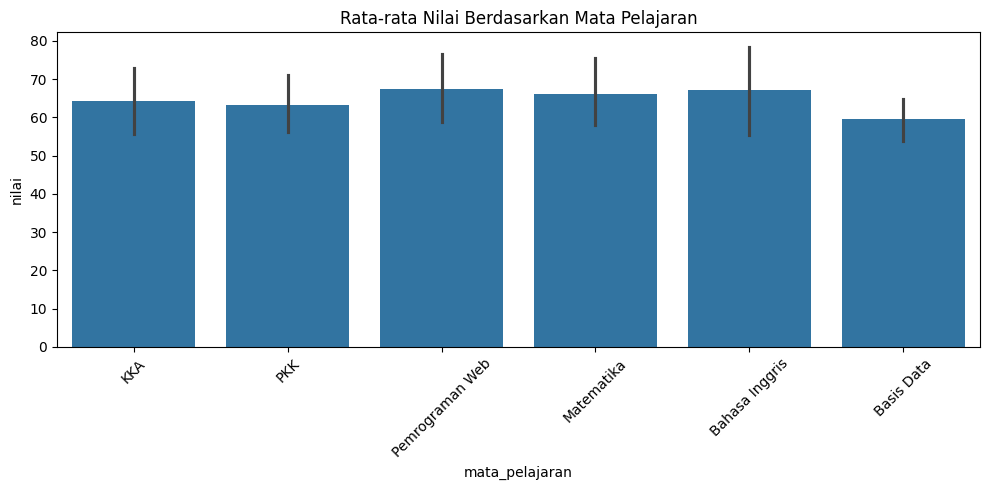

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="mata_pelajaran",
    y="nilai"
)

plt.title("Rata-rata Nilai Berdasarkan Mata Pelajaran")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Menyimpan data yang sudah dibersihkan
df.to_csv("dataset_nilai_akademik_bersih.csv", index=False)

print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!
